In [16]:
import numpy as truenp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

from lina.phase_retrieval import ADPR, FDPR, BBPR
from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import off_axis_3m_TMA
from algos import FFPR
import utils

from astropy import units as u


# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
batoid_log = logging.getLogger('__stp_batoid__')
psd_log.disabled = True
batoid_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [45]:
detector_data = utils.load_pickle('/home/derbyk/src/ffpr/data/detector_data.pkl')

platescale = 4.905 # arcsec/mm

w = 36 * platescale / 60
h = 24 * platescale / 60
w_offset = w / 2
h_offset = h / 2

positions = [(data['xy'][0] + w_offset, data['xy'][1] + h_offset) for data in detector_data]
defocuses = [float(data['defocus']) for data in detector_data]

In [46]:
src_pos = []
for position in positions:
    src_x = position[0] / 60         # positions [arcmin -> deg]
    src_y = position[1] / 60         # positions [arcmin -> deg]
    src_pos.append((src_x, src_y)) 

In [44]:
# raytrace = Lazuli_stop()

M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)


npix = 128
wvl = 633

npix = 128
dx = 3000 / npix

# zernike basis (excluding piston) up to Z37
x, y = make_xy_grid(npix, dx=dx)
r, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(2, 37)]
zernikes = list(zernike_nm_seq(nms, r, t, norm=True))
zernikes = [z / np.max(np.abs(z)) for z in zernikes]

pupil = circle(1500, r)

opds = []

for position in positions:
    x = position[0] / 60
    y = position[1] / 60

    ray_data = raytrace.get_OPD(fieldX=x, fieldY=y, npx=npix)
    opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) #* wvl
    opd[~pupil]

    opds.append(opd)

In [ ]:
# src_pos = [(0.18, -0.075),
#            (0.135, -0.037),
#            (0.09, 0),
#            (0.18, -0.15),
#            (0, 0),
#            (0, -0.075),
#            (0.27, -0.15),
#            (0, 0.075),
#            (0, -0.15),
#            (0.09, -0.15),
#            (0.18, 0.008),
#            (0.09, -0.075)]

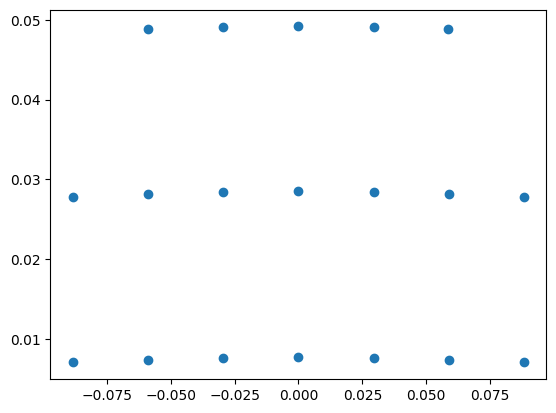

In [48]:
centroids_x = []
centroids_y = []

for pos in src_pos:

    # rv_2 = raytrace.get_footprint(surface='220mm CA dia. M2', fieldX=pos[0], fieldY=pos[1])
    rv_2 = raytrace.get_footprint(surface='380X220mm CA M3', fieldX=pos[0], fieldY=pos[1])
    

    ## Centroid method
    cx = np.sum(rv_2.x)/len(rv_2.x) 
    cy = np.sum(rv_2.y)/len(rv_2.y)

    centroids_x.append(cx)
    centroids_y.append(cy)

plt.scatter(x=centroids_x, y=centroids_y)

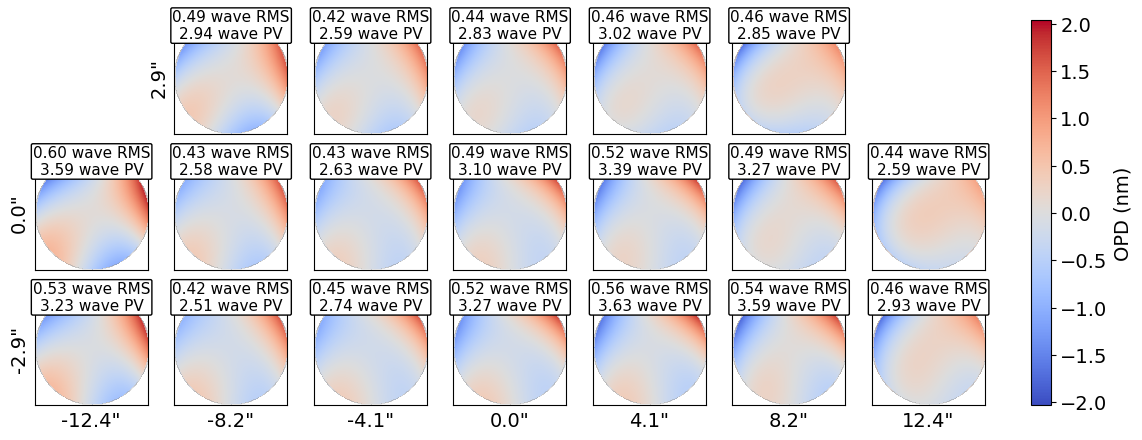

In [56]:
rms_vals = []
pv_vals = []

for opd in opds:
    opd[~pupil] = np.nan
    opd -= np.nanmean(opd)
    rms_vals.append(np.sqrt(np.nanmean(opd ** 2)))
    pv_vals.append(np.nanmax(opd) - np.nanmin(opd))

v1 = np.nanmax(np.array(opds))
v2 = np.abs(np.nanmin(np.array(opds)))
v = np.max(np.array([v1, v2]))

fig, axs = plt.subplots(ncols=7, nrows=3, figsize=(15, 5))
spec = plt.GridSpec(ncols=7, nrows=3)

count = 0
for i, ax in enumerate(axs.flat):
    if  i == 0 or i == 6:
        ax.axis('off')
    else:
        im = ax.imshow(opds[count].get(), cmap='coolwarm', vmax=v, vmin=-v)
        ax.set_xticks([])
        ax.set_yticks([])

        if count in (0, 5, 12):
            ax.set_ylabel(f'{positions[count][1]:.01f}"', fontsize=14)
        
        if count >= 12:
            ax.set_xlabel(f'{positions[count][0]:.01f}"', fontsize=14)

        l = f'{rms_vals[count]:.2f} wave RMS\n{pv_vals[count]:.2f} wave PV'
        c = "black"

        ax.text(64, 140, l,
                color=c, fontsize=11,
                ha='center', va='top',
                bbox=dict(facecolor='white', edgecolor=c, alpha=1, pad=0.1, boxstyle='round'))
        
        count += 1


cb = plt.colorbar(im, ax=axs, fraction=0.14, pad=0.04)
cb.set_label('OPD (nm)', fontsize=14)
cb.ax.tick_params(labelsize=14)
fig.set_tight_layout = True

In [59]:
m1_dx = 100e-6
m1_dy = 100e-6
m1_dz = 50e-6
m1_tx = 25e-6
m1_ty = 25e-6

m2_dx = 100e-6
m2_dy = 100e-6
m2_dz = 50e-6
m2_tx = 250e-6
m2_ty = 250e-6

In [92]:
samples = 1000

rms_data = np.zeros((samples, len(positions)))
pv_data = np.zeros((samples, len(positions)))

for i in range(samples):

    print('Iteration: ' + str(i + 1), end='\r')

    M1_motion = {'user_motion' : {'x' : truenp.random.uniform(low=-m1_dx / 2, high=m1_dx / 2), 
                                  'y' : truenp.random.uniform(low=-m1_dy / 2, high=m1_dy / 2), 
                                  'z' : truenp.random.uniform(low=-m1_dz / 2, high=m1_dz / 2), 
                                  'tip' : truenp.random.uniform(low=-m1_tx / 2, high=m1_tx / 2), 
                                  'tilt' : truenp.random.uniform(low=-m1_ty / 2, high=m1_ty / 2)}}
    M2_motion = {'user_motion' : {'x' : truenp.random.uniform(low=-m2_dx / 2, high=m2_dx / 2), 
                                  'y' : truenp.random.uniform(low=-m2_dy / 2, high=m2_dy / 2), 
                                  'z' : truenp.random.uniform(low=-m2_dz / 2, high=m2_dz / 2), 
                                  'tip' : truenp.random.uniform(low=-m2_tx / 2, high=m2_tx / 2), 
                                  'tilt' : truenp.random.uniform(low=-m2_ty / 2, high=m2_ty / 2)}}
    M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    opds = []

    for position in positions:
        x = position[0] / 60
        y = position[1] / 60

        ray_data = raytrace.get_OPD(fieldX=x, fieldY=y, npx=npix)
        opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) #* wvl
        opd[~pupil]

        opds.append(opd)

    for j, opd in enumerate(opds):
        opd[~pupil] = np.nan
        opd -= np.nanmean(opd)

        rms_data[i, j] = (np.sqrt(np.nanmean(opd ** 2)))
        pv_data[i, j] = (np.nanmax(opd) - np.nanmin(opd))

Text(0, 0.5, 'Waves PV')

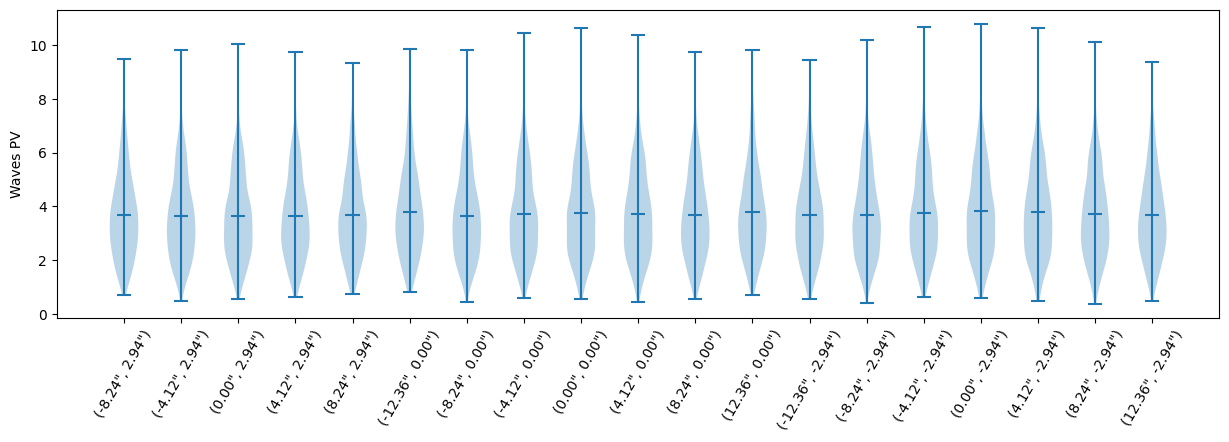

In [93]:
data = pv_data

plt.figure(figsize=(15, 4))
plt.violinplot(data.get(), showmeans=True)
plt.xticks(range(1, len(positions) + 1), [f'({p[0]:.2f}\", {p[1]:.2f}\")' for p in positions], rotation=60)
plt.ylabel('Waves PV')